In [1]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [3]:
# ----------------------------
# 1) LTM store (START EMPTY)
# ----------------------------
store = InMemoryStore()

In [4]:
# ----------------------------
# 2) System prompt
# ----------------------------
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible.

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""


In [5]:
# ----------------------------
# 3) Memory extraction LLM
# ----------------------------
memory_llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0)

In [6]:

class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory")
    is_new: bool = Field(description="True if new, false if duplicate")

class MemoryDecision(BaseModel):
    should_write: bool
    memories: List[MemoryItem] = Field(default_factory=list)

In [7]:
memory_extractor = memory_llm.with_structured_output(MemoryDecision)

In [20]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.

IMPORATNT: If there is nothing memory-worthy, return should_write=false and an empty list.
"""

In [21]:
# ----------------------------
# 4) Node 1: remember
# ----------------------------
def remember_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    ns = ("user", user_id, "details")

    # existing memory
    items = store.search(ns)
    existing = "\n".join(it.value["data"] for it in items) if items else "(empty)"

    # last user message
    last_msg = state["messages"][-1].content

    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=existing)),
            {"role": "user", "content": last_msg},
        ]
    )

    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(ns, str(uuid.uuid4()), {"data": mem.text})

    return {}  # no message change

In [22]:
# ----------------------------
# 5) Node 2: chat
# ----------------------------
chat_llm = ChatGroq(model="llama-3.1-8b-instant")

In [23]:
def chat_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    ns = ("user", user_id, "details")

    items = store.search(ns)
    user_details = "\n".join(it.value["data"] for it in items) if items else ""

    system_msg = SystemMessage(
        content=SYSTEM_PROMPT_TEMPLATE.format(
            user_details_content=user_details or "(empty)"
        )
    )

    response = chat_llm.invoke([system_msg] + state["messages"])
    return {"messages": [response]}

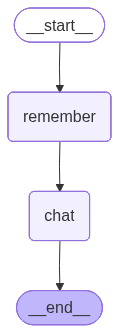

In [24]:
# ----------------------------
# 6) Graph
# ----------------------------
builder = StateGraph(MessagesState)
builder.add_node("remember", remember_node)
builder.add_node("chat", chat_node)

builder.add_edge(START, "remember")
builder.add_edge("remember", "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [13]:
# ----------------------------
# 7) Demo
# ----------------------------
config = {"configurable": {"user_id": "u1"}}

In [14]:
result = graph.invoke({"messages": [{"role": "user", "content": "Hi, my name is Nitish"}]}, config)
result['messages'][-1].content

"Nice to meet you, Nitish. It's great that you've started our conversation. I'll make sure to store your name for future interactions. Currently, I don't have any specific information about you or your preferences. How can I assist you today?"

In [15]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

Nitish


In [16]:
result = graph.invoke({"messages": [{"role": "user", "content": "I teach AI on YouTube"}]}, config)
print(result['messages'][-1].content)

It's great to see you, Nitish. I hear you're creating content around teaching AI on YouTube. That's fantastic! I've got a question for you - have you considered creating a series on Explainable AI (XAI)? With your expertise, you could make it easy for your viewers to grasp this complex topic.

Let me tell you a bit more about it. Explainable AI is crucial for building trust in AI systems, especially in areas like healthcare and finance. It's an emerging field that requires a solid understanding of AI concepts, as well as the ability to communicate them effectively. If you're interested, I can help you brainstorm some ideas for your XAI series.

By the way, which AI framework or library do you usually use for your YouTube tutorials? Is it TensorFlow, PyTorch, or perhaps OpenCV?

Here are three relevant further questions:

1. What inspired you to start teaching AI on YouTube?
2. Are there any specific AI topics or projects that you're planning to cover in your upcoming content?
3. Do you

In [17]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

Nitish
I teach AI on YouTube


In [25]:

result = graph.invoke({"messages": [{"role": "user", "content": "Explain GenAI simply"}]}, config)
print(result['messages'][-1].content)

Nitish, I'm glad you're teaching AI on YouTube - it's a fantastic way to share your knowledge with others. Now, let's talk about GenAI. 

GenAI, short for Generative Artificial Intelligence, is a type of AI that creates human-like content, such as text, images, music, or even videos. It works by analyzing patterns and structures in existing data and using that information to generate new content that's similar in style and quality.

Think of it like a super-smart copywriter, artist, or musician that can produce original work based on what it's learned from existing examples. GenAI is used in various applications, including language translation, content creation, and even product design.

For instance, if you're working on a YouTube video about AI, GenAI can help you generate scripts, thumbnails, or even entire sections of the video. It's an exciting field with endless possibilities, and I'm sure your students will love learning about it!

Here are three follow-up questions to further e

In [26]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

Nitish
I teach AI on YouTube
GenAI is a type of AI that generates human-like content


In [27]:
result = graph.invoke({"messages": [{"role": "user", "content": "what is llm?"}]}, config)
print(result['messages'][-1].content)

Nitish, you're probably aware that you've been exploring the realm of AI, especially with your teaching endeavors on YouTube. Considering you've got a solid grasp of GenAI, I thought I'd help you dive a bit deeper into another crucial topic in the AI world - LLMs.

Nitish, Large Language Models (LLMs) are a type of AI designed to process and understand vast amounts of natural language data. They're often trained on massive datasets of text from various sources, including books, articles, and conversations. This training enables LLMs to recognize patterns, relationships, and context within language.

Think of LLMs as highly advanced, language-capable computers that can comprehend and respond to diverse linguistic inputs, from simple queries to complex discussions. They're a vital component in many AI applications, including chatbots, language translation tools, and even your own YouTube content creation.

Now, I'd love to know more about your thoughts on this topic, Nitish. Have you exp

In [28]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

Nitish
I teach AI on YouTube
GenAI is a type of AI that generates human-like content
LLM stands for Large Language Model
